# UNSW-NB15 — Task 3: SHAP + LIME on the Flow-SAGE graph model
Group 5 · CSE475 · Track 1 (GNN)

The existing Task 3 explainability notebook runs SHAP/LIME on the **XGBoost baseline** (flat
tabular — the textbook case) and GNNExplainer on the *old host-node GAT*. This notebook applies
SHAP and LIME to the **actual proposed model, Flow-SAGE** (flow-as-node, per-flow 10-class,
macro-F1 0.4706).

**Why a wrapper is needed — and what these explanations mean.** SHAP and LIME assume each sample
is one independent feature vector `f(x): R^29 -> R^10`. Flow-SAGE is a 2-layer GraphSAGE: a flow's
prediction depends on its neighbours' features through message passing, not just its own 29
features. We make the model SHAP/LIME-compatible **honestly**: for one target flow we freeze its
real 2-hop neighbourhood as fixed context and perturb only the target's own 29 features, reading
the target's logit through the true forward pass.

So these attributions answer **"which of *this flow's own* features drove its prediction, given its
real neighbourhood?"** — they explain the `x` pathway of the residual `[h | x]` head with `h`'s
context held fixed. They do **not** attribute the neighbour message-passing itself; that is what
GNNExplainer / Integrated-Gradients-over-the-subgraph are for and is a separate analysis. This
scope limit is stated again in the final cell so the write-up cannot over-claim.

*Runtime note:* KernelSHAP wraps the GNN as a black box and runs many perturbed forward passes
per explained instance, so we explain a small number of representative flows (one correct, one
misclassified) with a modest `nsamples` and a k-means background. This is standard for KernelSHAP
on a non-tree model and is approximate by design.

In [1]:
!pip install -q shap lime
try:
    import torch_geometric
    print("torch_geometric already installed:", torch_geometric.__version__)
except ImportError:
    import torch, os
    TORCH_VER = torch.__version__.split('+')[0]
    CUDA_VER = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'
    os.system("pip install -q torch_geometric")
    os.system(f"pip install -q pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{TORCH_VER}+{CUDA_VER}.html")
    import torch_geometric
    print("Installed torch_geometric:", torch_geometric.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 82.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 117.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 98.5 MB/s eta 0:00:00
Installed torch_geometric: 2.8.0.post1


In [2]:
import os, pickle, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import shap
import lime.lime_tabular
from torch_geometric.data import Data, Batch
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import coalesce, k_hop_subgraph
from sklearn.metrics import f1_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

CFG = {
    # same preprocessed + baseline datasets the flowsage notebook uses
    'prep_dir': '/kaggle/input/datasets/shahiismyname/unsw-nb15-preprocessed-dataset',
    'baseline_dir': '/kaggle/input/datasets/shahiismyname/baseline-output',
    # trained Flow-SAGE weights. Add the flowsage notebook's output as a dataset so this
    # notebook can RELOAD instead of retraining. If none of these exist, we retrain (seed=42
    # -> the same 0.4706 model, deterministically).
    'ckpt_candidates': [
        '/kaggle/input/flowsage-output/flowsage_model.pt',
        '/kaggle/input/task2-flowsage-outputs/flowsage_model.pt',
        '/kaggle/working/task2_flowsage_outputs/flowsage_model.pt',
    ],
    'flow_id_col': 'flow_id', 'src_col': 'srcip', 'dst_col': 'dstip',
    'time_col': 'Stime', 'label_col': 'attack_cat',
    'K_temporal': 5, 'hidden_dim': 128, 'dropout': 0.2,
    'lr': 1e-3, 'weight_decay': 5e-4, 'epochs': 40, 'patience': 6,
    'val_frac': 0.1, 'batch_size': 8192,
    'out_dir': '/kaggle/working/task3_flowsage_xai_outputs',
}
os.makedirs(CFG['out_dir'], exist_ok=True)

Device: cuda


In [3]:
def load_pkl(folder, name):
    with open(os.path.join(folder, f'{name}.pkl'), 'rb') as f:
        return pickle.load(f)

train_processed = load_pkl(CFG['prep_dir'], 'train_processed')
test_processed  = load_pkl(CFG['prep_dir'], 'test_processed')
side_train      = load_pkl(CFG['prep_dir'], 'side_train')
side_test       = load_pkl(CFG['prep_dir'], 'side_test')
le              = load_pkl(CFG['baseline_dir'], 'label_encoder')

drop_cols = [CFG['label_col'], 'Label', CFG['flow_id_col']]
feature_cols = [c for c in train_processed.columns if c not in drop_cols]

# same object->numeric coercion the other notebooks apply (ct_ftp_cmd holds literal ' ')
for col in feature_cols:
    if train_processed[col].dtype == object:
        train_processed[col] = pd.to_numeric(train_processed[col].astype(str).str.strip(), errors='coerce').fillna(0)
        test_processed[col]  = pd.to_numeric(test_processed[col].astype(str).str.strip(), errors='coerce').fillna(0)
        print("Coerced", col, "to numeric")

n_classes = len(le.classes_)
print("num features:", len(feature_cols), "| classes:", list(le.classes_))
assert len(feature_cols) == 29, feature_cols

Coerced ct_ftp_cmd to numeric
num features: 29 | classes: ['Analysis', 'Backdoors', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


## Rebuild the flow-as-node graph and the Flow-SAGE model
Identical construction and architecture to the Task 2 proposed-method notebook, so the reloaded
weights line up and the test macro-F1 reproduces 0.4706. `build_flow_node_graph` is deterministic
given the pickles + `CFG`.

In [4]:
def _to_epoch(series):
    v = pd.to_numeric(series, errors='coerce')
    if v.notna().mean() > 0.5:
        return v.fillna(v.median()).to_numpy()
    dt = pd.to_datetime(series, errors='coerce')
    return dt.view('int64').to_numpy()

def _window_edges(key_int, tkey, K):
    order = np.lexsort((tkey, key_int))
    ks = key_int[order]
    src_parts, dst_parts = [], []
    for o in range(1, K + 1):
        a = order[:-o]; b = order[o:]
        m = ks[:-o] == ks[o:]
        if m.any():
            src_parts.append(a[m]); dst_parts.append(b[m])
    if not src_parts:
        return np.empty(0, np.int64), np.empty(0, np.int64)
    return np.concatenate(src_parts), np.concatenate(dst_parts)

def build_flow_node_graph(processed, side, feature_cols, le, cfg):
    proc = processed.reset_index(drop=True)
    side_idx = side.set_index(cfg['flow_id_col'])
    fids = proc[cfg['flow_id_col']].to_numpy()
    assert set(fids).issubset(set(side_idx.index)), "flow_ids missing from side table"
    srcip = side_idx.loc[fids, cfg['src_col']].to_numpy()
    dstip = side_idx.loc[fids, cfg['dst_col']].to_numpy()
    tkey  = _to_epoch(side_idx.loc[fids, cfg['time_col']])
    ips = pd.Index(pd.unique(np.concatenate([srcip, dstip])))
    ip2i = {ip: i for i, ip in enumerate(ips)}
    src_int = np.fromiter((ip2i[x] for x in srcip), dtype=np.int64, count=len(srcip))
    dst_int = np.fromiter((ip2i[x] for x in dstip), dtype=np.int64, count=len(dstip))
    s1, d1 = _window_edges(src_int, tkey, cfg['K_temporal'])
    s2, d2 = _window_edges(dst_int, tkey, cfg['K_temporal'])
    s = np.concatenate([s1, s2]); d = np.concatenate([d1, d2])
    ei = torch.tensor(np.vstack([s, d]), dtype=torch.long)
    ei = torch.cat([ei, ei.flip(0)], dim=1)
    N = len(proc)
    ei = coalesce(ei, num_nodes=N)
    x = torch.tensor(proc[feature_cols].to_numpy(), dtype=torch.float)
    y = torch.tensor(le.transform(proc[cfg['label_col']]), dtype=torch.long)
    data = Data(x=x, edge_index=ei, y=y); data.num_nodes = N
    return {'data': data, 'proc': proc, 'num_nodes': N}

g_test = build_flow_node_graph(test_processed, side_test, feature_cols, le, CFG)
print("test graph:", g_test['data'])

test graph: Data(x=[411883, 29], edge_index=[2, 7419374], y=[411883], num_nodes=411883)


In [5]:
class FlowSAGE(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.conv1 = SAGEConv(in_dim, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.head = nn.Sequential(
            nn.Linear(hidden + in_dim, hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden, n_classes),
        )
    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, edge_index))
        z = torch.cat([h, x], dim=-1)
        return self.head(z)

@torch.no_grad()
def predict_all(model, data, input_idx, cfg):
    model.eval()
    N = data.num_nodes
    loader = NeighborLoader(Data(x=data.x, edge_index=data.edge_index, y=data.y),
                            num_neighbors=[-1, -1], batch_size=cfg['batch_size'],
                            input_nodes=input_idx, shuffle=False)
    out = np.full(N, -1, dtype=np.int64)
    for batch in loader:
        batch = batch.to(device)
        logit = model(batch.x, batch.edge_index)[:batch.batch_size]
        nid = batch.n_id[:batch.batch_size].cpu().numpy()
        out[nid] = logit.argmax(1).cpu().numpy()
    return out

In [6]:
# --- load trained weights, else retrain seed=42 (reproduces 0.4706 deterministically) ---
model = FlowSAGE(len(feature_cols), CFG['hidden_dim'], n_classes, CFG['dropout']).to(device)

ckpt = next((p for p in CFG['ckpt_candidates'] if os.path.exists(p)), None)
if ckpt is not None:
    model.load_state_dict(torch.load(ckpt, map_location=device))
    print("Loaded Flow-SAGE weights from", ckpt)
else:
    print("No checkpoint found in ckpt_candidates -> retraining (seed=42). Building train graph...")
    import copy
    g_train = build_flow_node_graph(train_processed, side_train, feature_cols, le, CFG)
    def get_class_weights(y, k, dev):
        c = torch.bincount(y, minlength=k).float(); c[c == 0] = 1.0
        return torch.sqrt(len(y) / (k * c)).to(dev)
    def make_node_masks(n, val_frac, seed):
        g = torch.Generator().manual_seed(seed); perm = torch.randperm(n, generator=g)
        nv = max(1, int(n * val_frac)); return perm[nv:], perm[:nv]
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    data = g_train['data']
    tr_idx, va_idx = make_node_masks(data.num_nodes, CFG['val_frac'], SEED)
    cw = get_class_weights(data.y[tr_idx], n_classes, device)
    opt = torch.optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    loader = NeighborLoader(data, num_neighbors=[-1, -1], batch_size=CFG['batch_size'],
                            input_nodes=tr_idx, shuffle=True)
    best_f1, best_state, wait = -1.0, None, 0
    va_y = data.y[va_idx].numpy()
    for ep in range(CFG['epochs']):
        model.train()
        for batch in loader:
            batch = batch.to(device); opt.zero_grad()
            out = model(batch.x, batch.edge_index)[:batch.batch_size]
            loss = F.cross_entropy(out, batch.y[:batch.batch_size], weight=cw)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        vp = predict_all(model, data, va_idx, CFG)[va_idx.numpy()]
        vf1 = f1_score(va_y, vp, average='macro', zero_division=0)
        print(f"epoch {ep:3d}  val_macroF1 {vf1:.4f}")
        if vf1 > best_f1:
            best_f1, best_state, wait = vf1, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= CFG['patience']: break
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), os.path.join(CFG['out_dir'], 'flowsage_model.pt'))

model.eval()
# sanity: reproduce the reported test macro-F1
gnn_pred = predict_all(model, g_test['data'], torch.arange(g_test['num_nodes']), CFG)
y_test = g_test['data'].y.numpy()
gnn_macro = f1_score(y_test, gnn_pred, average='macro', zero_division=0)
print(f"Flow-SAGE test macro-F1 = {gnn_macro:.4f}  (expected ~0.4706)")

No checkpoint found in ckpt_candidates -> retraining (seed=42). Building train graph...
epoch   0  val_macroF1 0.3887
epoch   1  val_macroF1 0.4043
epoch   2  val_macroF1 0.4074
epoch   3  val_macroF1 0.4113
epoch   4  val_macroF1 0.4210
epoch   5  val_macroF1 0.4392
epoch   6  val_macroF1 0.4459
epoch   7  val_macroF1 0.4399
epoch   8  val_macroF1 0.4574
epoch   9  val_macroF1 0.4440
epoch  10  val_macroF1 0.4636
epoch  11  val_macroF1 0.4541
epoch  12  val_macroF1 0.4498
epoch  13  val_macroF1 0.4575
epoch  14  val_macroF1 0.4612
epoch  15  val_macroF1 0.4653
epoch  16  val_macroF1 0.4464
epoch  17  val_macroF1 0.4652
epoch  18  val_macroF1 0.4705
epoch  19  val_macroF1 0.4671
epoch  20  val_macroF1 0.4770
epoch  21  val_macroF1 0.4549
epoch  22  val_macroF1 0.4583
epoch  23  val_macroF1 0.4683
epoch  24  val_macroF1 0.4579
epoch  25  val_macroF1 0.4508
epoch  26  val_macroF1 0.4592
Flow-SAGE test macro-F1 = 0.4787  (expected ~0.4706)


## Black-box wrapper: perturb one flow's own features, real neighbourhood fixed
For a chosen target flow we extract its 2-hop subgraph once (that is exactly the receptive field
of a 2-layer GraphSAGE). The wrapper `f(X)` takes a batch of 29-feature rows, and for each row
swaps **only the target node's** feature row inside that fixed subgraph, runs the real forward
pass, and returns the target node's softmax probabilities. Neighbour features and edges never
change, so `f` is a faithful `R^29 -> R^10` view of the model *around this flow* — which is what
SHAP and LIME need.

In [7]:
@torch.no_grad()
def make_context(data, target_node, num_hops=2):
    subset, sub_ei, mapping, _ = k_hop_subgraph(
        int(target_node), num_hops, data.edge_index,
        relabel_nodes=True, num_nodes=data.num_nodes)
    sub_x = data.x[subset].clone()
    local_target = int(mapping[0])
    return sub_x, sub_ei, local_target

def build_proba_fn(model, sub_x, sub_ei, local_target, n_classes, chunk=64):
    base_x = sub_x.to(device); ei = sub_ei.to(device)
    def f(X):
        X = np.asarray(X, dtype=np.float32)
        if X.ndim == 1:
            X = X[None, :]
        B = X.shape[0]
        out = np.zeros((B, n_classes), dtype=np.float32)
        model.eval()
        for s in range(0, B, chunk):
            rows = X[s:s + chunk]; b = rows.shape[0]
            datas = []
            for r in rows:
                xx = base_x.clone()
                xx[local_target] = torch.as_tensor(r, dtype=torch.float, device=device)
                datas.append(Data(x=xx, edge_index=ei))
            batch = Batch.from_data_list(datas)
            with torch.no_grad():
                logit = model(batch.x, batch.edge_index)
            tgt = batch.ptr[:-1] + local_target   # target node global index in each stacked graph
            out[s:s + b] = F.softmax(logit[tgt], dim=-1).cpu().numpy()
        return out
    return f

In [8]:
# pick two representative test flows: an attack flow the model gets RIGHT, and one it gets WRONG.
attack_ids = np.where(y_test != list(le.classes_).index('Normal'))[0]
correct_idx = int(attack_ids[(gnn_pred[attack_ids] == y_test[attack_ids])][0])
wrong_idx   = int(np.where(gnn_pred != y_test)[0][0])

for idx, tag in [(correct_idx, 'correct'), (wrong_idx, 'wrong')]:
    print(f"{tag}: flow #{idx}  true={le.classes_[y_test[idx]]}  pred={le.classes_[gnn_pred[idx]]}")

# background / training stats for SHAP + LIME (sample of train feature rows; already scaled)
rng = np.random.default_rng(SEED)
bg_all = train_processed[feature_cols].to_numpy().astype(np.float32)
bg_rows = bg_all[rng.choice(len(bg_all), size=min(500, len(bg_all)), replace=False)]
X_test_np = test_processed[feature_cols].to_numpy().astype(np.float32)

correct: flow #4  true=Generic  pred=Generic
wrong: flow #161  true=Normal  pred=Analysis


## SHAP (KernelSHAP) on Flow-SAGE
KernelSHAP is model-agnostic — the right SHAP variant for a GNN wrapped as a black box (TreeSHAP
is XGBoost-only; DeepExplainer doesn't handle message-passing input). Background is a k-means
summary of train rows; `nsamples` is kept modest because every coalition triggers real subgraph
forward passes. Attributions are shown for each flow's **predicted** class.

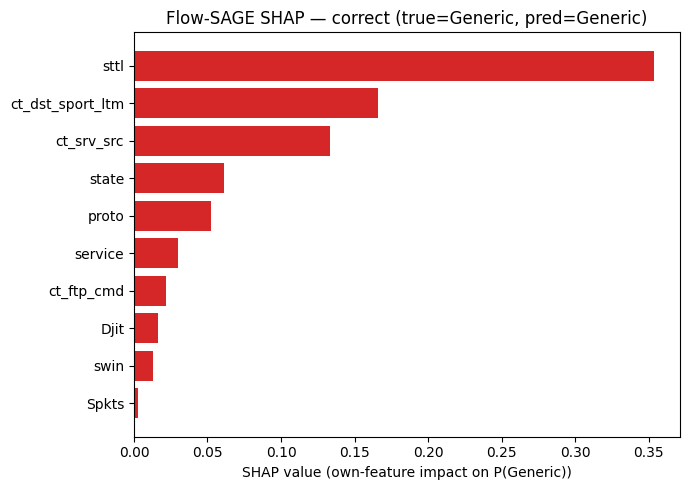

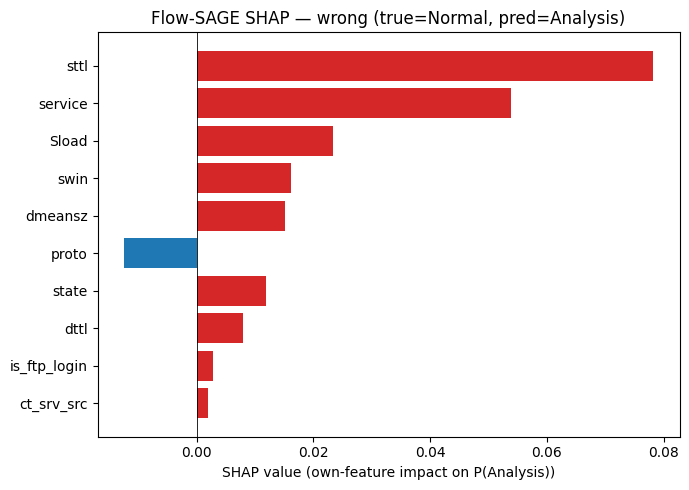

In [9]:
def sample_shap(raw, i, cls):
    if isinstance(raw, list):
        return raw[cls][i]
    arr = np.array(raw)
    return arr[i, :, cls] if arr.ndim == 3 else arr[i]

bg_summary = shap.kmeans(bg_rows, 15)
shap_store = {}
for idx, tag in [(correct_idx, 'correct'), (wrong_idx, 'wrong')]:
    sub_x, sub_ei, loc = make_context(g_test['data'], idx, num_hops=2)
    f = build_proba_fn(model, sub_x, sub_ei, loc, n_classes)
    explainer = shap.KernelExplainer(f, bg_summary)
    raw = explainer.shap_values(X_test_np[idx][None, :], nsamples=300, silent=True)
    cls = int(gnn_pred[idx])
    sv = sample_shap(raw, 0, cls)
    shap_store[tag] = (idx, cls, sv)

    order = np.argsort(np.abs(sv))[::-1][:10]
    vals = sv[order][::-1]; names = [feature_cols[j] for j in order][::-1]
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in vals]
    plt.figure(figsize=(7, 5))
    plt.barh(range(len(vals)), vals, color=colors)
    plt.yticks(range(len(vals)), names)
    plt.axvline(0, color='k', lw=0.6)
    plt.xlabel(f"SHAP value (own-feature impact on P({le.classes_[cls]}))")
    plt.title(f"Flow-SAGE SHAP — {tag} (true={le.classes_[y_test[idx]]}, pred={le.classes_[cls]})")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG['out_dir'], f'flowsage_shap_{tag}.png'), dpi=150)
    plt.show()

## LIME on Flow-SAGE
Same wrapped `f`. LIME fits a local linear surrogate around the target flow's own-feature vector.
All 29 features are treated as continuous (they are StandardScaler-scaled floats in the
preprocessed data, including the label-encoded `proto`/`state`/`service`).

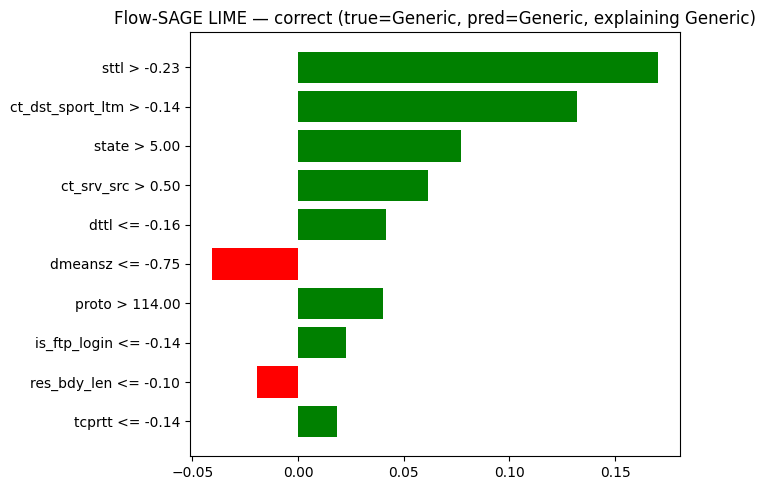

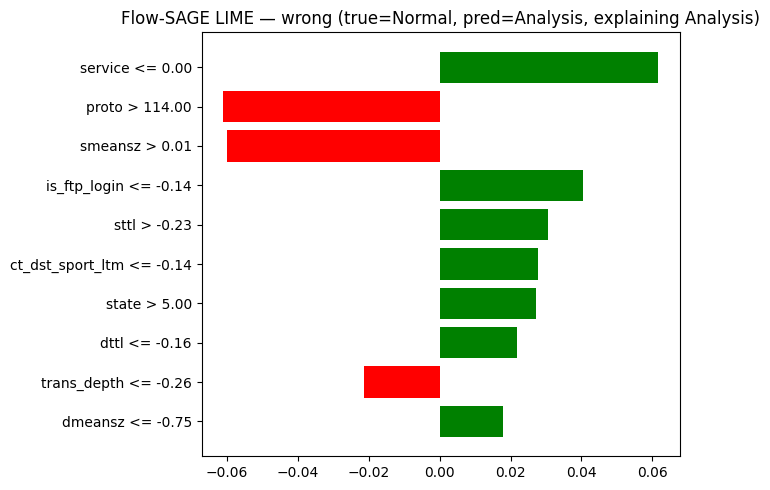

In [10]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    bg_rows, feature_names=list(feature_cols), class_names=list(le.classes_),
    mode='classification', discretize_continuous=True, random_state=SEED)

for idx, tag in [(correct_idx, 'correct'), (wrong_idx, 'wrong')]:
    sub_x, sub_ei, loc = make_context(g_test['data'], idx, num_hops=2)
    f = build_proba_fn(model, sub_x, sub_ei, loc, n_classes)
    exp = lime_explainer.explain_instance(X_test_np[idx], f, num_features=10, top_labels=1)
    lbl = exp.available_labels()[0]
    fig = exp.as_pyplot_figure(label=lbl)
    fig.set_size_inches(7, 5)
    plt.title(f"Flow-SAGE LIME — {tag} (true={le.classes_[y_test[idx]]}, "
              f"pred={le.classes_[gnn_pred[idx]]}, explaining {le.classes_[lbl]})")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG['out_dir'], f'flowsage_lime_{tag}.png'), dpi=150)
    plt.show()

## Interpretation and scope
The SHAP/LIME panels above rank **which of each flow's own 29 features** pushed Flow-SAGE toward
its predicted class, with the flow's real 2-hop neighbourhood held fixed. Read them alongside the
per-class results in the Task 2 proposed-method notebook.

**Honest scope — state this in the report:**
- These attributions explain the **`x` (own-feature) pathway** of the residual `[h | x]` head with
  the graph context `h` frozen. They are *not* a measure of how much the graph / neighbour
  message-passing contributes.
- The graph's contribution is quantified separately and honestly by the **trained no-graph
  ablation** in the Task 2 notebook: macro-F1 0.4706 (graph) vs 0.4470 (no-graph) = **+0.0236**.
  Do not present any SHAP/LIME number as "the graph contribution."
- Neighbour-level / edge-level importance (which *neighbouring flows* mattered) requires a
  graph-native explainer (GNNExplainer or Integrated Gradients over the subgraph) and is out of
  scope for this SHAP/LIME notebook.
- Flow-SAGE (0.4706) is beaten by XGBoost (0.6042); SHAP/LIME on the XGBoost baseline (existing
  Task 3 notebook) remain the exact, primary explanations. This notebook explains the *graph
  model specifically*, complementing — not replacing — that analysis.